# Práctica 01: pronóstico de producción eléctrica

Aplicación de Box–Jenkins al índice mensual de producción eléctrica (`IPG2211A2N`), siguiendo el flujo de los materiales de clase: datos, gráfico, ADF, diferenciación, FAC/FACP, AR/MA/ARMA/ARIMA, pronóstico y diagnóstico.

## 1. Librerías

Si se utiliza otro entorno, instalar primero: `%pip install yfinance pandas numpy matplotlib statsmodels`.

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tools.sm_exceptions import InterpolationWarning

plt.rcParams['figure.figsize'] = (10, 4)
alpha = 0.05

## 2. Llamado al dataset

Se usa el mismo dataset de producción eléctrica del material de clase. La carga se hace directamente desde una fuente pública y queda únicamente en memoria dentro del notebook.

In [2]:
url = 'https://gist.githubusercontent.com/tuanorai/660f1966f4df3a373c8e7e9867f7e299/raw/Electric_production.csv'
data = pd.read_csv(url)
data['DATE'] = pd.to_datetime(data['DATE'])
data = data.sort_values('DATE').set_index('DATE')
serie = data['IPG2211A2N'].dropna().astype(float)
if len(serie) < 80: raise ValueError('Se necesitan al menos 80 observaciones.')
print(f'Producción eléctrica: {len(serie)} observaciones')
print(f'Desde {serie.index.min().date()} hasta {serie.index.max().date()}')

Producción eléctrica: 397 observaciones
Desde 1985-01-01 hasta 2018-01-01


## 3. Dataset y preparación

`Open`, `High`, `Low` y `Close` son precios en USD; `Volume` es el volumen reportado. La variable del modelo será **Close**.

In [3]:
print('Dimensiones:', data.shape)
print('Periodo:', data.index.min().date(), 'a', data.index.max().date())
display(data.head())
display(data.tail())
data.info()

Dimensiones: (397, 1)
Periodo: 1985-01-01 a 2018-01-01


,IPG2211A2N
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


,IPG2211A2N
DATE,
2017-09-01,98.6154
2017-10-01,93.6137
2017-11-01,97.3359
2017-12-01,114.7212
2018-01-01,129.4048


<class 'pandas.DataFrame'>
DatetimeIndex: 397 entries, 1985-01-01 to 2018-01-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IPG2211A2N  397 non-null    float64
dtypes: float64(1)
memory usage: 6.2 KB


In [4]:
display(data.describe().T)
display(data.isna().sum().rename('Nulos').to_frame())
print('Fechas duplicadas:', data.index.duplicated().sum())

,count,mean,std,min,25%,50%,75%,max
IPG2211A2N,397.0,88.847218,15.387834,55.3151,77.1052,89.7795,100.5244,129.4048


,Nulos
IPG2211A2N,0


Fechas duplicadas: 0


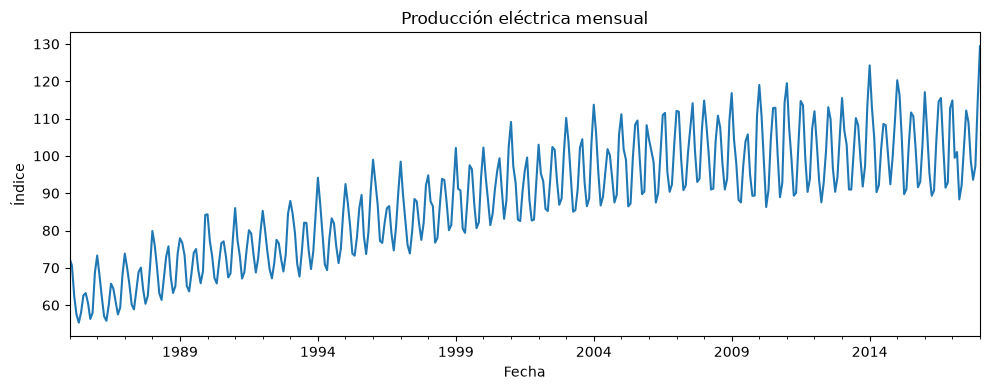

In [5]:
data = data.loc[~data.index.duplicated(keep='first')].copy()
serie = data['IPG2211A2N'].astype(float).dropna()
serie.index = serie.index.to_period('M').to_timestamp()
serie = serie.asfreq('MS')
if (serie <= 0).any(): raise ValueError('Hay valores no positivos.')
serie.plot(title='Producción eléctrica mensual', ylabel='Índice', xlabel='Fecha')
plt.tight_layout(); plt.show()

## 4. Fase 1: identificación y estacionariedad

### 4.1. División temporal

El primer 80 % se utiliza para identificar y ajustar el modelo. El último 20 % se reserva para evaluar el pronóstico. Las pruebas y la elección de parámetros usan solamente `train`.

,Datos,Desde,Hasta
Entrenamiento,317,1985-01-01,2011-05-01
Prueba,80,2011-06-01,2018-01-01


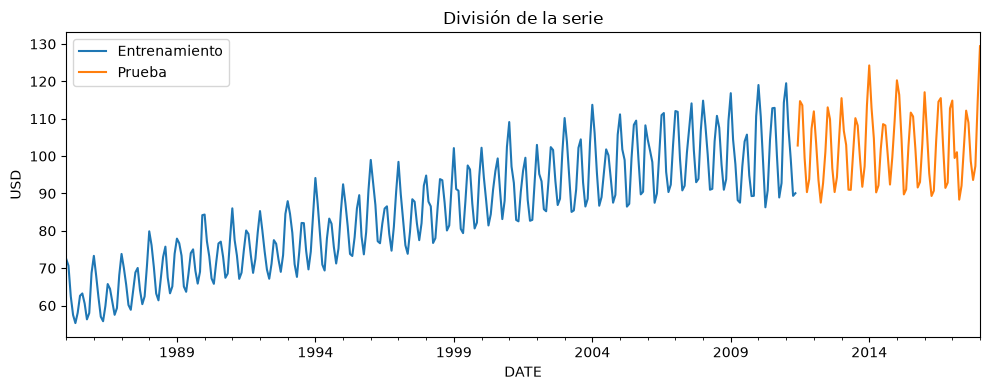

In [6]:
corte = int(len(serie) * 0.8)
train = serie.iloc[:corte]
test = serie.iloc[corte:]

display(pd.DataFrame({
    'Datos': [len(train), len(test)],
    'Desde': [train.index.min().date(), test.index.min().date()],
    'Hasta': [train.index.max().date(), test.index.max().date()]
}, index=['Entrenamiento', 'Prueba']))

train.plot(label='Entrenamiento')
test.plot(label='Prueba')
plt.title('División de la serie')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Estacionariedad

ADF: H₀ = la serie no es estacionaria; Hₐ = la serie es estacionaria. Si p-valor < 0,05 se rechaza H₀.

In [7]:
def prueba_adf(x, nombre):
    r = adfuller(x.dropna(), autolag='AIC', result_object=False)
    print(f'{nombre}: ADF={r[0]:.4f}; p-valor={r[1]:.4f};', 'estacionaria' if r[1] < alpha else 'no estacionaria')
    return r[1]
corte = int(len(serie) * 0.8)
train, test = serie.iloc[:corte], serie.iloc[corte:]
p0 = prueba_adf(train, 'Original')

Original: ADF=-1.7387; p-valor=0.4113; no estacionaria


### Diferenciación

Se revisan d=0, d=1 y d=2. Se usa el menor orden que pase ADF.

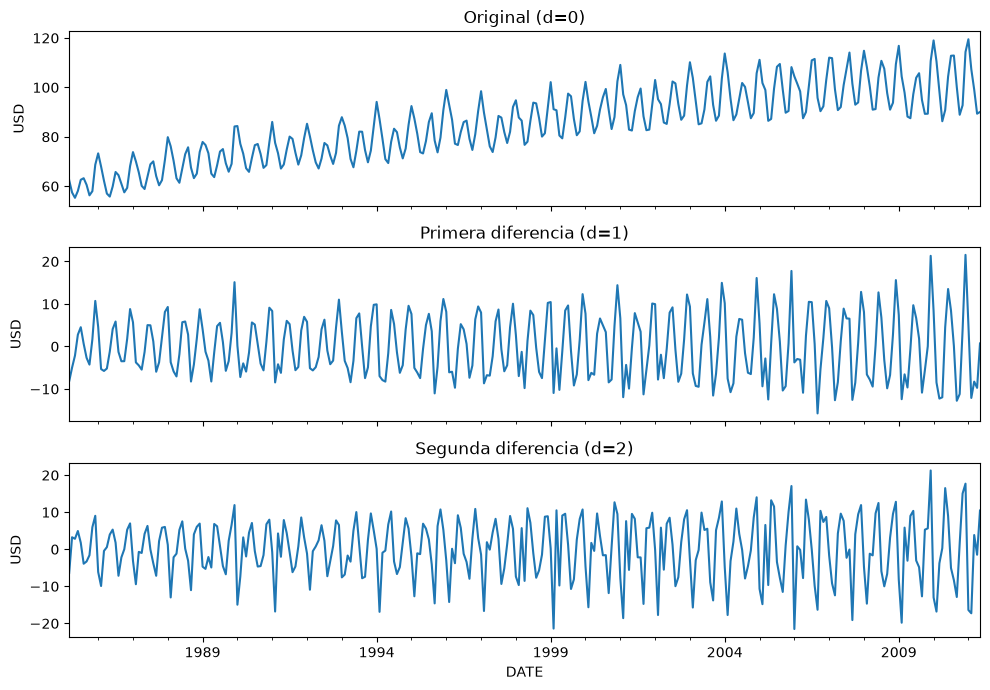

In [8]:
train_diff = train.diff().dropna()
train_diff2 = train_diff.diff().dropna()
series = [train, train_diff, train_diff2]
nombres = ['Original (d=0)', 'Primera diferencia (d=1)', 'Segunda diferencia (d=2)']

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for x, nombre, ax in zip(series, nombres, axes):
    x.plot(ax=ax, title=nombre)
    ax.set_ylabel('USD')
plt.tight_layout()
plt.show()

In [9]:
p1 = prueba_adf(train_diff, 'Primera diferencia')
p2 = prueba_adf(train_diff2, 'Segunda diferencia')
if p0 < alpha: d = 0
elif p1 < alpha: d = 1
elif p2 < alpha: d = 2
else: raise ValueError('No se logró estacionariedad con d=0, 1 o 2.')
serie_estacionaria = [train, train_diff, train_diff2][d]
print(f'Orden elegido: d={d}')
serie_estacionaria = [train, train_diff, train_diff2][d]


Primera diferencia: ADF=-6.3530; p-valor=0.0000; estacionaria
Segunda diferencia: ADF=-10.2643; p-valor=0.0000; estacionaria
Orden elegido: d=1


### 4.6. FAC y FACP para identificar p y q

| Modelo sobre la serie estacionaria | FAC | FACP |
|---|---|---|
| AR(p) | Decae gradualmente | Corte después de p |
| MA(q) | Corte después de q | Decae gradualmente |
| ARMA(p,q) | Decae gradualmente | Decae gradualmente |

Estos patrones son orientativos. Se comparan órdenes pequeños con AIC y BIC para apoyar la elección.

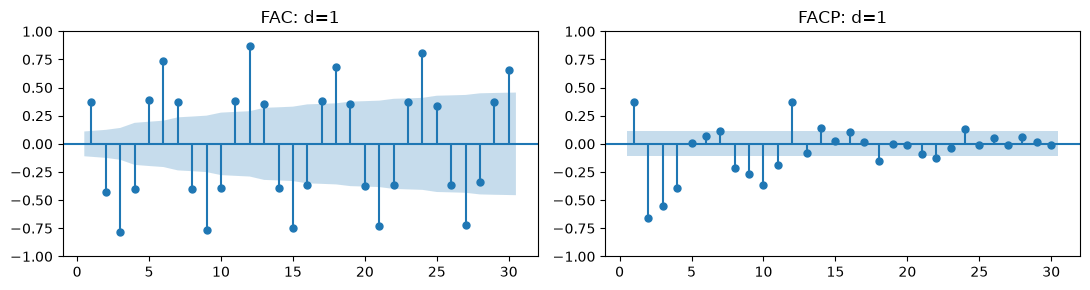

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(serie_estacionaria, lags=30, zero=False, ax=axes[0], title=f'FAC: d={d}')
plot_pacf(serie_estacionaria, lags=30, zero=False, method='ywm', ax=axes[1],
          title=f'FACP: d={d}')
plt.tight_layout()
plt.show()

## 5. Fase 2: estimación y comparación de modelos

Con `d=0`, ARIMA(p,0,0) es AR, ARIMA(0,0,q) es MA y ARIMA(p,0,q) es ARMA. Con `d>0`, el modelo de la serie original es **ARIMA(p,d,q)**, aunque las diferencias se modelen con AR, MA o ARMA.

Se prueban `p` y `q` entre 0 y 3. Se incluye ARIMA(0,1,0), un paseo aleatorio sin deriva, cuando `d=1`. Se ajusta **train original**: ARIMA realiza las diferencias internamente y devuelve pronósticos en USD. Se usa constante si `d=0` y sin tendencia determinista si `d>0`.

In [11]:
modelos, resultados = {}, []
trend = 'c' if d == 0 else 'n'
for p in range(3):
    for q in range(3):
        orden = (p, d, q)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                ajuste = ARIMA(train, order=orden, trend=trend, freq='MS').fit()
            if np.isfinite(ajuste.aic):
                modelos[orden] = ajuste
                resultados.append({'Orden': orden, 'AIC': ajuste.aic, 'BIC': ajuste.bic})
        except (ValueError, np.linalg.LinAlgError): pass
if not resultados: raise ValueError('No se pudo ajustar ningún modelo.')
comparacion = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
display(comparacion)
orden_elegido = tuple(comparacion.loc[0, 'Orden'])
modelo = modelos[orden_elegido]
print('Modelo elegido por AIC: ARIMA', orden_elegido)
nombre = f'ARIMA{orden_elegido}'


,Orden,AIC,BIC
0,"(2, 1, 2)",1649.048015,1667.826726
1,"(2, 1, 1)",1763.321188,1778.344157
2,"(2, 1, 0)",1924.475746,1935.742972
3,"(1, 1, 2)",1955.011227,1970.034196
4,"(0, 1, 2)",1981.514822,1992.782048
5,"(0, 1, 1)",2049.667812,2057.179297
6,"(1, 1, 1)",2051.360556,2062.627782
7,"(1, 1, 0)",2105.600250,2113.111734
8,"(0, 1, 0)",2150.439230,2154.194972


Modelo elegido por AIC: ARIMA (2, 1, 2)


## 6. Fase 3: diagnóstico de residuos

### 6.1. Selección con AIC y Ljung–Box

Un AIC menor indica un mejor equilibrio entre ajuste y complejidad dentro de esta comparación. Siguiendo Box–Jenkins, se revisan los modelos en ese orden y se elige el primero sin autocorrelación residual detectada a 10 y 20 rezagos.

Ljung–Box: H₀ = no hay autocorrelación hasta el rezago evaluado. Se descartan los residuos iniciales de inicialización y se descuentan `p+q` grados de libertad. Pasar esta prueba no garantiza independencia ni varianza constante.

In [12]:
residuales = modelo.resid.dropna()
print('Residuos disponibles:', len(residuales))

Residuos disponibles: 317


### 6.2. Gráficos de los residuos

### 6.3. Ljung–Box, ARCH y Jarque–Bera

ARCH contrasta ausencia de heterocedasticidad condicional; Jarque–Bera contrasta normalidad. Si p < 0,05 se rechaza su hipótesis nula. Una media próxima a cero se revisa descriptivamente.

In [13]:
lb = acorr_ljungbox(residuales, lags=[10], return_df=True)
arch = het_arch(residuales, nlags=10, result_object=False)
jb = jarque_bera(residuales)
pruebas = pd.DataFrame({'Prueba':['Ljung–Box','ARCH','Jarque–Bera'], 'Estadístico':[lb['lb_stat'].iloc[0],arch[0],jb[0]], 'p-valor':[lb['lb_pvalue'].iloc[0],arch[1],jb[1]]})
display(pruebas)
print(f'Media de residuos: {residuales.mean():.4f}')

,Prueba,Estadístico,p-valor
0,Ljung–Box,12.490197,0.253587
1,ARCH,15.654701,0.109953
2,Jarque–Bera,182332.712205,0.000000


Media de residuos: 0.3061


## 7. Fase 4: pronóstico y evaluación

### 7.1. Pronóstico del conjunto de prueba

El modelo queda fijado antes de consultar los errores de prueba. Se pronostica todo el bloque desde el último día de entrenamiento, sin actualizar con valores de `test`. Se compara con una referencia ingenua: repetir el último cierre conocido.

Los intervalos del 95 % dependen de los supuestos del modelo; su cobertura puede ser inadecuada si ARCH o Jarque–Bera rechazan sus hipótesis.

,Real,Pronóstico,Ingenuo,Inferior 95%,Superior 95%
2011-06-01,102.8204,101.799347,90.0698,95.552701,108.045994
2011-07-01,114.7068,108.693175,90.0698,100.127894,117.258455
2011-08-01,113.5958,103.852875,90.0698,93.707179,113.998570
2011-09-01,99.4712,92.131884,90.0698,80.637396,103.626373
2011-10-01,90.3566,85.268884,90.0698,72.398793,98.138975


,Real,Pronóstico,Ingenuo,Inferior 95%,Superior 95%
2017-09-01,98.6154,91.621600,90.0698,40.807858,142.435341
2017-10-01,93.6137,85.494804,90.0698,34.349117,136.640491
2017-11-01,97.3359,90.866872,90.0698,39.344799,142.388945
2017-12-01,114.7212,102.352155,90.0698,50.455716,154.248595
2018-01-01,129.4048,108.448449,90.0698,56.225612,160.671287


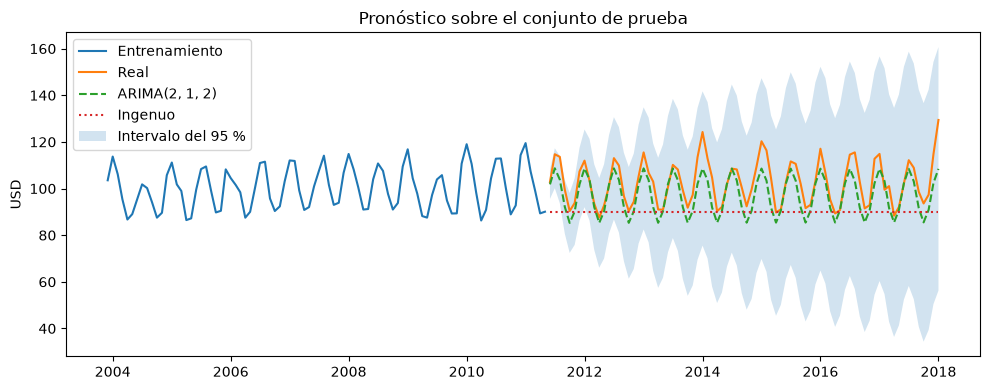

In [14]:
pronostico = modelo.get_forecast(steps=len(test))
intervalo = pronostico.conf_int(alpha=alpha)
prediccion = pronostico.predicted_mean

evaluacion = pd.DataFrame({'Real': test, 'Pronóstico': prediccion,
                           'Ingenuo': train.iloc[-1],
                           'Inferior 95%': intervalo.iloc[:, 0],
                           'Superior 95%': intervalo.iloc[:, 1]})
display(evaluacion.head())
display(evaluacion.tail())

plt.plot(train.tail(90), label='Entrenamiento')
plt.plot(test, label='Real')
plt.plot(prediccion, label=nombre, linestyle='--')
plt.plot(test.index, evaluacion['Ingenuo'], label='Ingenuo', linestyle=':')
plt.fill_between(test.index, intervalo.iloc[:, 0], intervalo.iloc[:, 1],
                 alpha=0.2, label='Intervalo del 95 %')
plt.title('Pronóstico sobre el conjunto de prueba')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

### 7.2. Errores del pronóstico

MSE, RMSE, MAE y MAPE: cuanto menores, mejor. RMSE y MAE se expresan en USD, MSE en USD² y MAPE en porcentaje. Las métricas del bloque completo se complementan con sus primeros 30 días, un horizonte más corto.

In [15]:
def metricas(real, estimado):
    error = real - estimado
    mse = np.mean(error ** 2)
    return {'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.mean(np.abs(error)),
            'MAPE (%)': np.mean(np.abs(error / real)) * 100}

metricas_test = pd.DataFrame({
    nombre: metricas(test, evaluacion['Pronóstico']),
    'Ingenuo': metricas(test, evaluacion['Ingenuo'])
}).T
print('Todo el conjunto de prueba:')
display(metricas_test.round(2))
print('Primeros 30 días de prueba:')
display(pd.DataFrame({
    nombre: metricas(test.iloc[:30], evaluacion['Pronóstico'].iloc[:30]),
    'Ingenuo': metricas(test.iloc[:30], evaluacion['Ingenuo'].iloc[:30])
}).T.round(2))

Todo el conjunto de prueba:


,MSE,RMSE,MAE,MAPE (%)
"ARIMA(2, 1, 2)",49.34,7.02,5.69,5.40
Ingenuo,251.48,15.86,12.78,11.71


Primeros 30 días de prueba:


,MSE,RMSE,MAE,MAPE (%)
"ARIMA(2, 1, 2)",26.38,5.14,4.41,4.34
Ingenuo,193.93,13.93,11.32,10.60


### 7.3. Reajuste y pronóstico de 30 días posteriores al dataset

Se conserva el orden elegido y se reestiman los parámetros con toda la serie. El horizonte empieza después de la última fecha descargada; este pronóstico no es una evaluación con datos observados.

,Pronóstico,Inferior 95%,Superior 95%
2018-02-01,126.27,119.68,132.86
2018-03-01,114.15,105.04,123.27
2018-04-01,105.17,94.34,116.01
2018-05-01,108.30,96.06,120.54
2018-06-01,120.41,106.79,134.03
2018-07-01,129.38,114.33,144.44
2018-08-01,126.26,109.83,142.69
2018-09-01,114.17,96.57,131.77
2018-10-01,105.20,86.65,123.75
2018-11-01,108.31,88.91,127.72


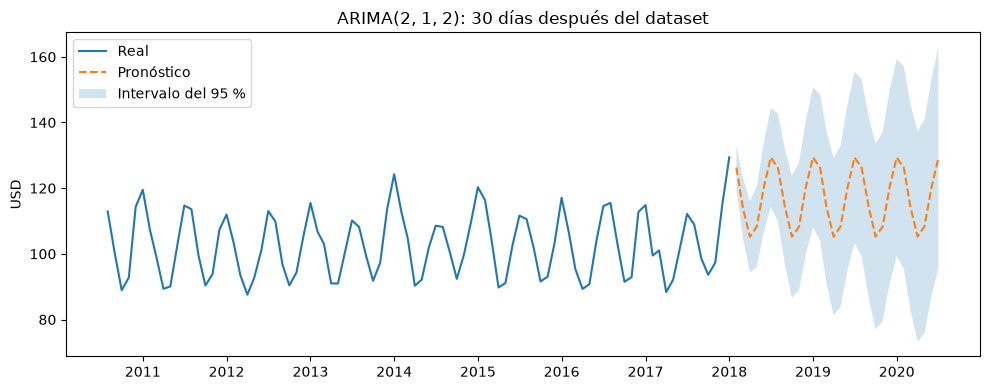

In [16]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    modelo_final = ARIMA(serie, order=orden_elegido, trend=trend, freq='MS').fit(method_kwargs={'maxiter': 200})
if not modelo_final.mle_retvals.get('converged', False):
    raise ValueError('El reajuste final no convergió. Revisar antes de pronosticar.')

futuro = modelo_final.get_forecast(steps=30)
intervalo_futuro = futuro.conf_int(alpha=alpha)
tabla_futuro = pd.DataFrame({'Pronóstico': futuro.predicted_mean,
                             'Inferior 95%': intervalo_futuro.iloc[:, 0],
                             'Superior 95%': intervalo_futuro.iloc[:, 1]})
display(tabla_futuro.round(2))

plt.plot(serie.tail(90), label='Real')
plt.plot(tabla_futuro['Pronóstico'], label='Pronóstico', linestyle='--')
plt.fill_between(tabla_futuro.index, tabla_futuro['Inferior 95%'],
                 tabla_futuro['Superior 95%'], alpha=0.2, label='Intervalo del 95 %')
plt.title(f'ARIMA{orden_elegido}: 30 días después del dataset')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusiones

In [17]:
print(f'1. Se analizaron {len(serie)} observaciones mensuales de producción eléctrica.')
print(f'2. Se seleccionó d={d}, según la prueba ADF.')
print(f'3. El modelo elegido por AIC fue ARIMA{orden_elegido}.')
print(f'4. RMSE del pronóstico: {metricas_test.loc[nombre, "RMSE"]:.2f}.')
print('5. Las pruebas de residuos se muestran en la tabla anterior.')
print('6. El pronóstico es una estimación; no reproduce exactamente cada variación futura.')

1. Se analizaron 397 observaciones mensuales de producción eléctrica.
2. Se seleccionó d=1, según la prueba ADF.
3. El modelo elegido por AIC fue ARIMA(2, 1, 2).
4. RMSE del pronóstico: 7.02.
5. Las pruebas de residuos se muestran en la tabla anterior.
6. El pronóstico es una estimación; no reproduce exactamente cada variación futura.


### Referencias

Material de clase: `01. Introducción a la programación para Series de Tiempo.ipynb`, `02. Series estacionarias y no estacionarias.ipynb`, `04. Modelos ARMA.ipynb` y los tres PDF de `TeoriayScrips`.

Consulta técnica: [yfinance](https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html), [ARIMA](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html), [KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html) y [Ljung–Box](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html).